In [ ]:
%pip install numpy
%pip install pandas
%pip install seaborn
%pip install statsmodels
%pip install scipy
%pip install matplotlib

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy.stats import f_oneway
import numpy as np
import os
from app import ingest

In [3]:
PROCESSED_REVENUE_DATA_FILEPATH = "processed_revenue_data.csv"
TRAIN_DATA_FOLDER_PATH = "cs-train"
PRODUCTION_DATA_FOLDER_PATH = "cs-production"

In [4]:
df = ingest.ingest_data(
    [TRAIN_DATA_FOLDER_PATH, PRODUCTION_DATA_FOLDER_PATH], PROCESSED_REVENUE_DATA_FILEPATH, 10)
print(f"Processed DataFrame shape: {df.shape}")
df.head()

Found 26 JSON files across 2 folders: ['cs-train', 'cs-production']
Selecting top 10 ...
Top 10 countries by revenue: ['United Kingdom', 'EIRE', 'France', 'Germany', 'Norway', 'Singapore', 'Hong Kong', 'Portugal', 'Netherlands', 'Belgium']
Processed data saved to 'processed_revenue_data.csv'.
Processed DataFrame shape: (177, 6)


,year,month,country,revenue,times_viewed,date
0,2017,11,Belgium,130.00,1.0,2017-11-01
1,2017,11,EIRE,570.21,737.0,2017-11-01
2,2017,11,France,352.42,704.0,2017-11-01
3,2017,11,Germany,156.48,374.0,2017-11-01
4,2017,11,Netherlands,49.33,240.0,2017-11-01


In [5]:
min_date = df['date'].min()
max_date = df['date'].max()
days = (max_date - min_date).days
print(f"Approximate range in days: {days}")


Approximate range in days: 730


In [6]:
df.dtypes

year                     int64
month                    int64
country                 object
revenue                float64
times_viewed           float64
date            datetime64[ns]
dtype: object

# Hypotheses

## H1. Revenue exhibits seasonal patterns that vary by country

Different countries may have unique purchasing behaviors tied to holidays, cultural events, or economic cycles, which the model must account for.

**Test**: Aggregate revenue by month and country for the top 10 countries.

**Expected:** Significant seasonal peaks with country-specific variations

In [7]:
df = pd.read_csv(PROCESSED_REVENUE_DATA_FILEPATH)

# Get top 10 countries
top_10_countries = df['country'].unique()
if len(top_10_countries) != 10:
    print(f"Warning: Found {len(top_10_countries)} countries instead of 10.")

print(f"Countries analyzed: {top_10_countries}")

Countries analyzed: ['Belgium' 'EIRE' 'France' 'Germany' 'Netherlands' 'Portugal'
 'United Kingdom' 'Norway' 'Hong Kong' 'Singapore']


In [8]:
# Time-Series Decomposition

# Initialize dictionaries for results
seasonal_components = {}
monthly_avg_revenue = {}

# Perform decomposition for each country
for country in top_10_countries:
    # Filter data for the country
    df_country = df[df['country'] == country][['date', 'revenue']].set_index('date')
    
    # Ensure monthly frequency (fill missing months with 0)
    df_country = df_country.asfreq('MS', fill_value=0)  # MS = Month Start
    
    # Log number of months for diagnostics
    non_zero_months = len(df[df['country'] == country])
    print(f"{country}: {non_zero_months} non-zero months, {len(df_country)} total months after filling.")
    
    # Perform decomposition (period = 12 for monthly data)
    if len(df_country) >= 24:  # Need at least 2 years
        try:
            decomposition = seasonal_decompose(df_country['revenue'], model='additive', period=12)
            seasonal_components[country] = pd.Series(decomposition.seasonal.values, 
                                                    index=decomposition.seasonal.index, 
                                                    name='seasonal')
        except Exception as e:
            print(f"Decomposition failed for {country}: {e}")
            seasonal_components[country] = pd.Series(0, index=df_country.index, name='seasonal')
    else:
        print(f"Insufficient data for {country} (<24 months). Using zero seasonal component.")
        seasonal_components[country] = pd.Series(0, index=df_country.index, name='seasonal')
    
    # Calculate average revenue per calendar month
    df_country_monthly = df[df['country'] == country].groupby('month')['revenue'].mean().reindex(range(1, 13), fill_value=0)
    monthly_avg_revenue[country] = df_country_monthly

Belgium: 21 non-zero months, 25 total months after filling.
EIRE: 21 non-zero months, 25 total months after filling.
France: 21 non-zero months, 25 total months after filling.
Germany: 21 non-zero months, 25 total months after filling.
Netherlands: 21 non-zero months, 25 total months after filling.
Portugal: 21 non-zero months, 25 total months after filling.
United Kingdom: 21 non-zero months, 25 total months after filling.
Norway: 13 non-zero months, 21 total months after filling.
Insufficient data for Norway (<24 months). Using zero seasonal component.
Hong Kong: 12 non-zero months, 20 total months after filling.
Insufficient data for Hong Kong (<24 months). Using zero seasonal component.
Singapore: 5 non-zero months, 19 total months after filling.
Insufficient data for Singapore (<24 months). Using zero seasonal component.


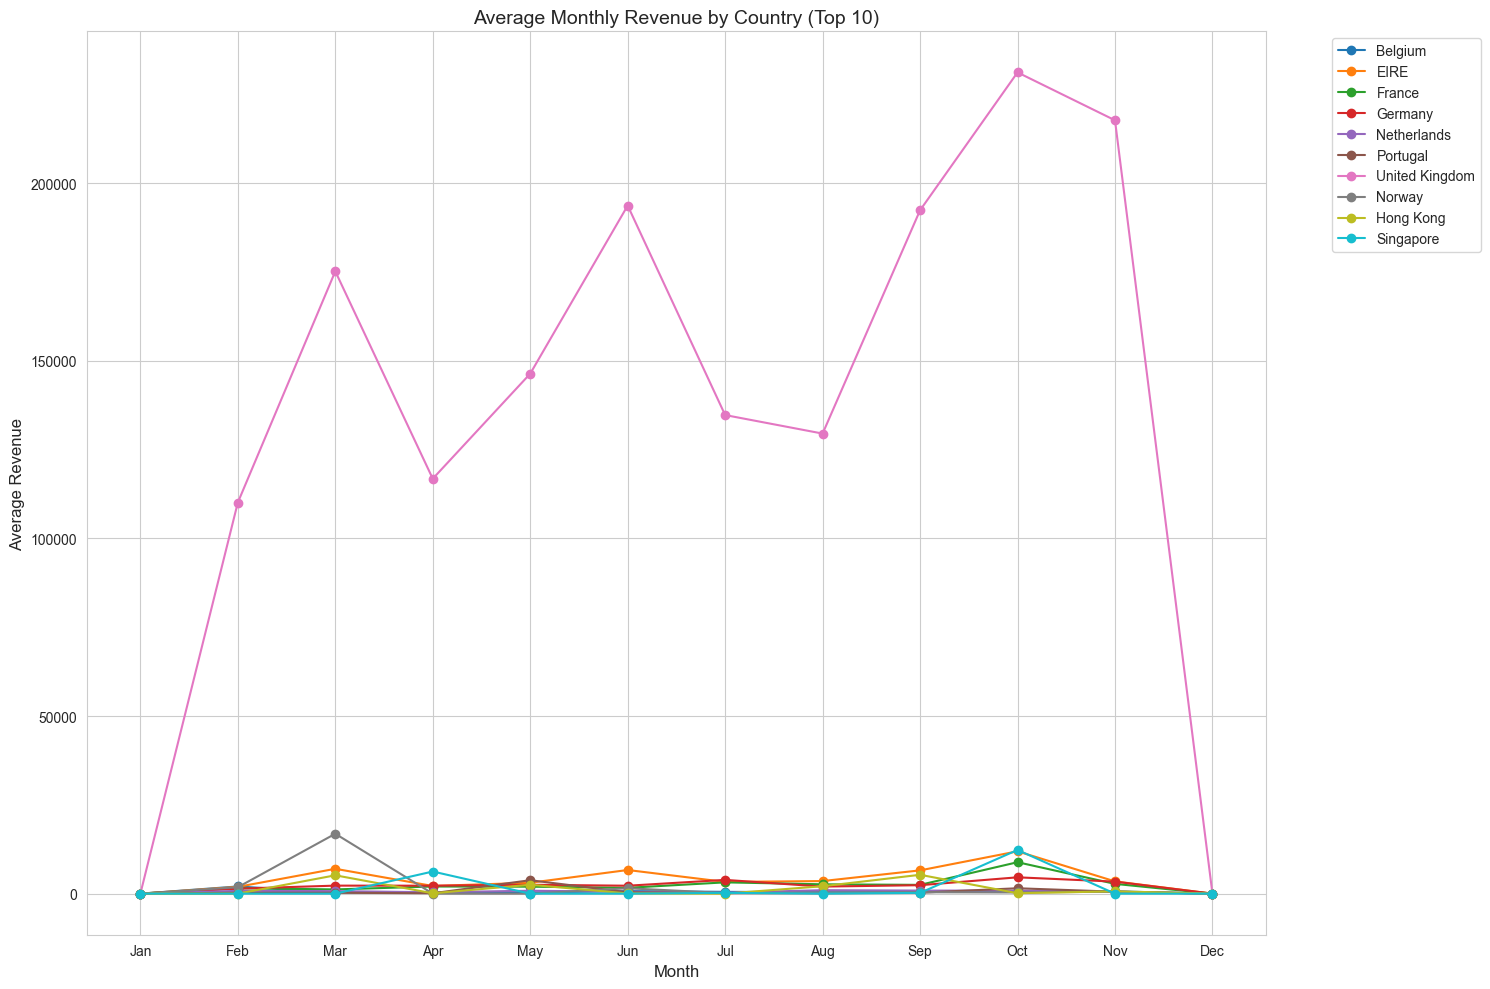

In [9]:
# Monthly Revenue Trends

# Plot average revenue by month
plt.figure(figsize=(15, 10))
sns.set_style("whitegrid")

for country in top_10_countries:
    plt.plot(monthly_avg_revenue[country].index, monthly_avg_revenue[country].values, label=country, marker='o')

plt.title("Average Monthly Revenue by Country (Top 10)", fontsize=14)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Average Revenue", fontsize=12)
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## H2. The top 10 countries account for the majority of à la carte revenue.

Limiting the model to the top 10 countries assumes they dominate revenue, justifying the scope reduction.

**Test**: Sum price by country across all data. 

**Expected**: Top 10 countries contribute >80% of revenue, supporting the focus on them.

In [10]:

majority_threshold = 0.8  # 80% as "majority"

df = ingest.ingest_data(
    input_folders=[TRAIN_DATA_FOLDER_PATH, PRODUCTION_DATA_FOLDER_PATH])
print(f"Processed DataFrame shape: {df.shape}")
df.head()



Found 26 JSON files across 2 folders: ['cs-train', 'cs-production']
Processed DataFrame shape: (495, 6)


,year,month,country,revenue,times_viewed,date
0,2017,11,Australia,40.40,97.0,2017-11-01
1,2017,11,Belgium,130.00,1.0,2017-11-01
2,2017,11,Denmark,2.10,15.0,2017-11-01
3,2017,11,EIRE,570.21,737.0,2017-11-01
4,2017,11,France,352.42,704.0,2017-11-01


In [11]:
countries_list = df["country"].drop_duplicates().tolist()
country_count = len(countries_list)
country_count

43

In [12]:
# Calculate Revenue by Country
# Sum revenue by country
country_revenue = df.groupby('country')['revenue'].sum().sort_values(ascending=False)

# Identify top 10 countries
top_10_countries = country_revenue.head(10)
top_10_revenue = top_10_countries.sum()

# Calculate total revenue
total_revenue = country_revenue.sum()

# Compute proportion for top 10
top_10_proportion = top_10_revenue / total_revenue

# Display results
print(f"Top 10 countries by revenue:\n{top_10_countries}")
print(f"\nTotal revenue: {total_revenue:.2f}")
print(f"Top 10 revenue: {top_10_revenue:.2f}")
print(f"Proportion from top 10: {top_10_proportion:.4f} ({top_10_proportion*100:.2f}%)")

Top 10 countries by revenue:
country
United Kingdom    3512678.023
EIRE               102602.000
France              59243.080
Germany             57166.681
Norway              40450.580
Singapore           25218.060
Hong Kong           20778.020
Portugal            15399.760
Netherlands         14104.500
Belgium             13566.870
Name: revenue, dtype: float64

Total revenue: 3955372.84
Top 10 revenue: 3861207.57
Proportion from top 10: 0.9762 (97.62%)


In [13]:
# Test H2: Proportion > threshold
print(f"\nH2: The top 10 countries account for the majority of à la carte revenue")
print(f"Majority threshold: {majority_threshold*100}%")
if top_10_proportion > majority_threshold:
    print(f"Result: H2 supported. Top 10 countries contribute {top_10_proportion*100:.2f}% of revenue, exceeding {majority_threshold*100}%.")
else:
    print(f"Result: H2 not supported. Top 10 countries contribute {top_10_proportion*100:.2f}% of revenue, below {majority_threshold*100}%.")


H2: The top 10 countries account for the majority of à la carte revenue
Majority threshold: 80.0%
Result: H2 supported. Top 10 countries contribute 97.62% of revenue, exceeding 80.0%.


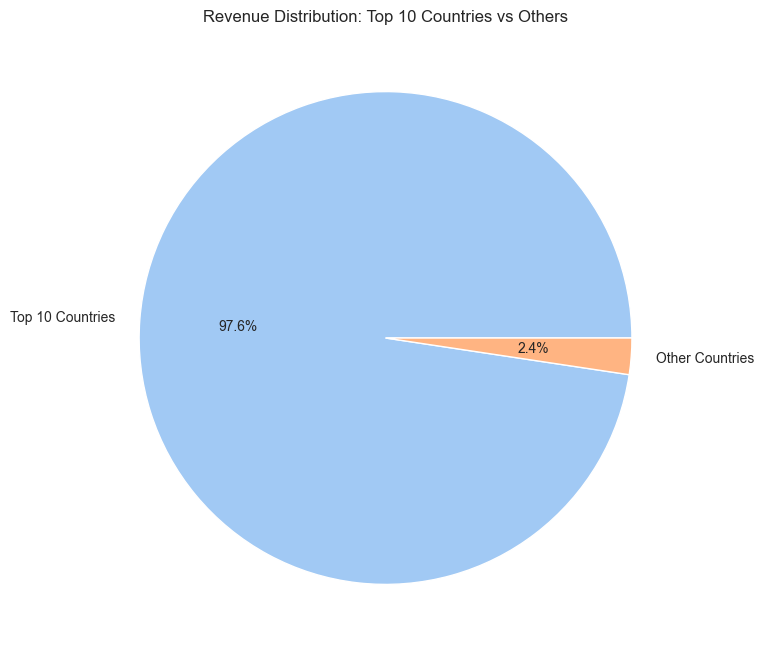

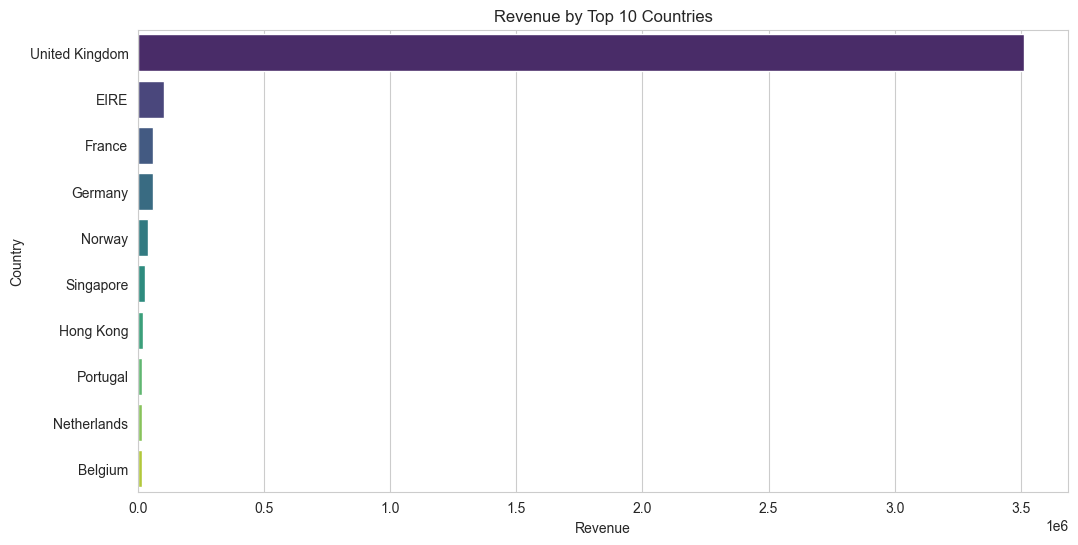

In [14]:
# Plot

other_revenue = total_revenue - top_10_revenue
plot_data = pd.Series({
    'Top 10 Countries': top_10_revenue,
    'Other Countries': other_revenue
})

# pie chart
plt.figure(figsize=(8, 8))
plt.pie(plot_data, labels=plot_data.index, autopct='%1.1f%%', colors=sns.color_palette("pastel"))
plt.title("Revenue Distribution: Top 10 Countries vs Others")
plt.show()

# bar chart for top 10
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_countries.values, y=top_10_countries.index, hue=top_10_countries.index, palette="viridis", legend=False)
plt.title("Revenue by Top 10 Countries")
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.show()

# EDA

In [15]:
df = ingest.ingest_data(
    input_folders=[TRAIN_DATA_FOLDER_PATH])
print(f"Processed DataFrame shape: {df.shape}")

Found 21 JSON files across 1 folders: ['cs-train']
Processed DataFrame shape: (396, 6)


In [16]:
df.head()

,year,month,country,revenue,times_viewed,date
0,2017,11,Australia,40.40,97.0,2017-11-01
1,2017,11,Belgium,130.00,1.0,2017-11-01
2,2017,11,Denmark,2.10,15.0,2017-11-01
3,2017,11,EIRE,570.21,737.0,2017-11-01
4,2017,11,France,352.42,704.0,2017-11-01


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396 entries, 0 to 395
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   year          396 non-null    int64         
 1   month         396 non-null    int64         
 2   country       396 non-null    object        
 3   revenue       396 non-null    float64       
 4   times_viewed  396 non-null    float64       
 5   date          396 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(2), object(1)
memory usage: 18.7+ KB


In [18]:
# Statistics
print(df[['revenue', 'times_viewed']].describe())

             revenue   times_viewed
count     396.000000     396.000000
mean     7626.767025    2944.303030
std     34633.660899   19987.555964
min         1.060000       0.000000
25%        78.737500       0.000000
50%       218.855000       0.000000
75%       815.367500     260.500000
max    313246.222000  193538.000000


## Check Missing Data and Data Coverage

Missing Values:
year            0
month           0
country         0
revenue         0
times_viewed    0
date            0
dtype: int64

Months per Country (Sorted):
country
Bermuda                  1
RSA                      1
West Indies              1
Saudi Arabia             1
Nigeria                  2
Lithuania                2
Czech Republic           2
Brazil                   2
Lebanon                  2
Thailand                 2
Malta                    2
Korea                    3
European Community       3
Singapore                4
Iceland                  4
Israel                   5
Bahrain                  5
Canada                   6
United Arab Emirates     7
USA                      8
Hong Kong                8
Unspecified              9
Norway                   9
Greece                  11
Finland                 12
Cyprus                  13
Poland                  13
Italy                   14
Japan                   15
Channel Islands         15
Austria        

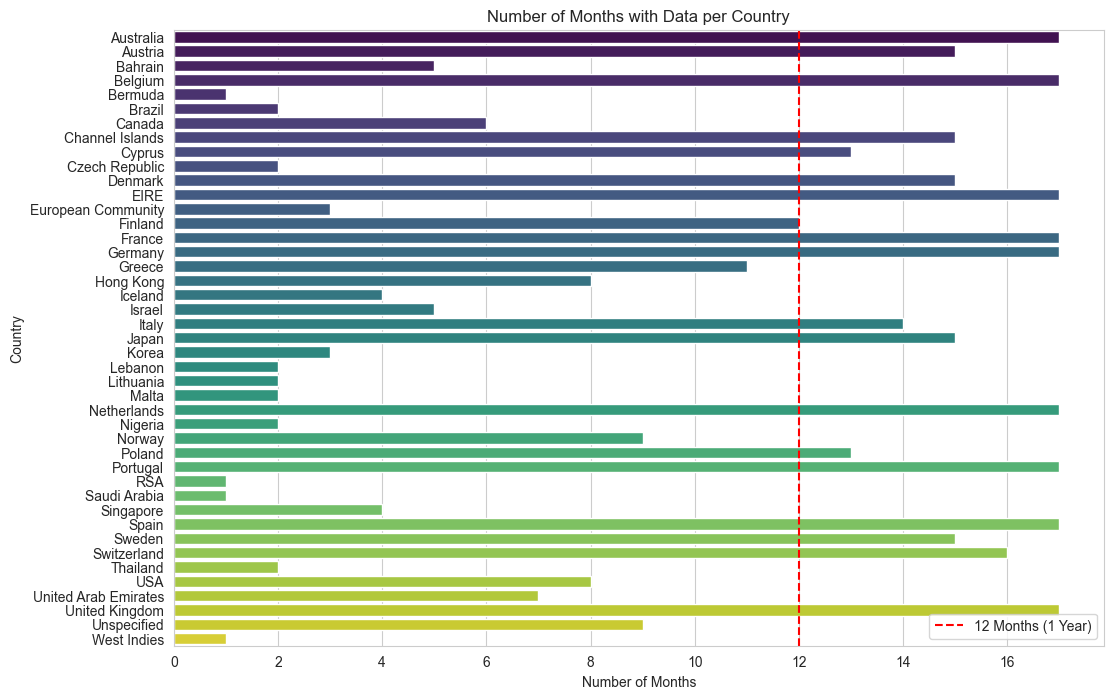


Date Range: 2017-11-01 00:00:00 to 2019-07-01 00:00:00
Average Months per Country: 9.2


In [19]:
# Check for missing values
print("Missing Values:")
print(df.isna().sum())

# Number of months per country
months_per_country = df.groupby('country')['date'].nunique()
sparse_countries = months_per_country[months_per_country < 12].index
print("\nMonths per Country (Sorted):")
print(months_per_country.sort_values())
print(f"\nSparse Countries (<12 months): {list(sparse_countries)}")

# Plot months per country
plt.figure(figsize=(12, 8))
sns.barplot(x=months_per_country.values, y=months_per_country.index, hue=months_per_country.index, palette="viridis", legend=False)
plt.title("Number of Months with Data per Country")
plt.xlabel("Number of Months")
plt.ylabel("Country")
plt.axvline(x=12, color='red', linestyle='--', label='12 Months (1 Year)')
plt.legend()
plt.show()

# Date range and average months
min_date = df['date'].min()
max_date = df['date'].max()
avg_months = months_per_country.mean()
print(f"\nDate Range: {min_date} to {max_date}")
print(f"Average Months per Country: {avg_months:.1f}")

## Revenue Distribution by Country

Total Revenue by Country (Top 10 and Others):
country
United Kingdom    2689830.701
EIRE                85284.530
Germany             40084.421
Norway              38033.850
France              33390.960
Hong Kong           14273.710
Singapore           12912.580
Portugal            12044.220
Netherlands         10965.460
Belgium             10222.080
Name: revenue, dtype: float64

Other Countries: 73157.23
Total Revenue: 3020199.74
Top 10 Proportion: 0.9758 (97.58%)


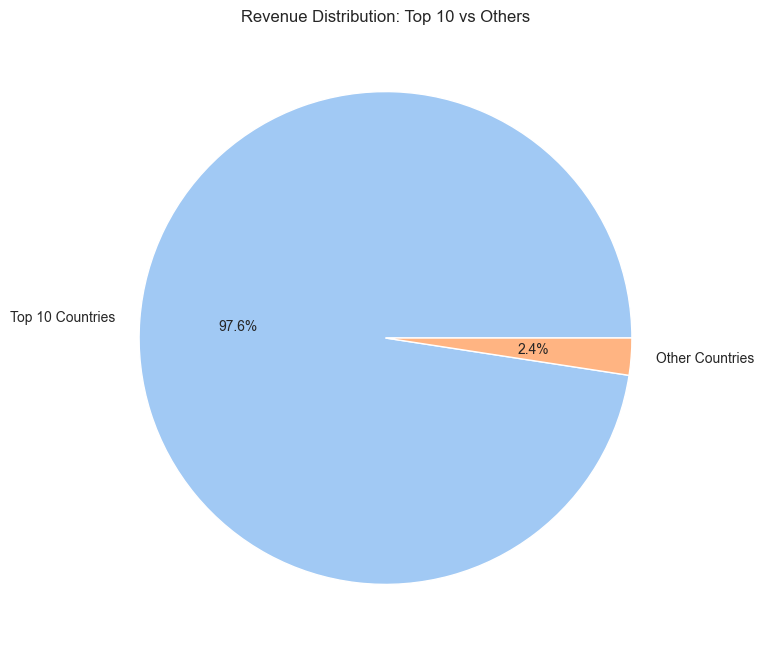

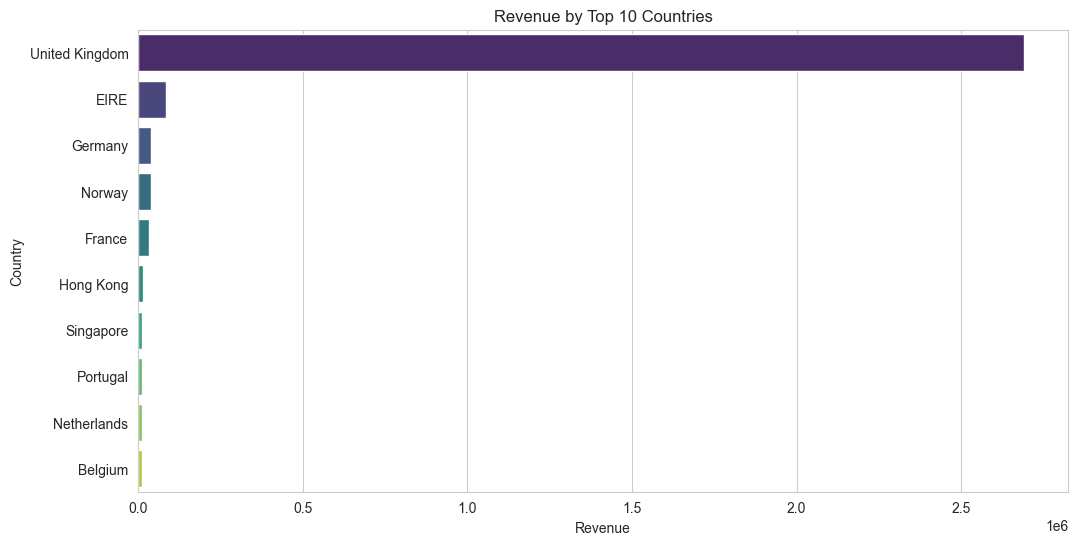

In [20]:
# Total revenue by country
country_revenue = df.groupby('country')['revenue'].sum().sort_values(ascending=False)

# Top 10 and others
top_10_countries = country_revenue.head(10)
other_revenue = country_revenue[10:].sum()
total_revenue = country_revenue.sum()
top_10_proportion = top_10_countries.sum() / total_revenue

# Print stats
print("Total Revenue by Country (Top 10 and Others):")
print(top_10_countries)
print(f"\nOther Countries: {other_revenue:.2f}")
print(f"Total Revenue: {total_revenue:.2f}")
print(f"Top 10 Proportion: {top_10_proportion:.4f} ({top_10_proportion*100:.2f}%)")

# Pie chart
plot_data = pd.Series({
    'Top 10 Countries': top_10_countries.sum(),
    'Other Countries': other_revenue
})
plt.figure(figsize=(8, 8))
plt.pie(plot_data, labels=plot_data.index, autopct='%1.1f%%', colors=sns.color_palette("pastel"))
plt.title("Revenue Distribution: Top 10 vs Others")
plt.show()

# Bar chart for top 10
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_countries.values, y=top_10_countries.index, hue=top_10_countries.index, palette="viridis", legend=False)
plt.title("Revenue by Top 10 Countries")
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.show()

## Revenue Distribution Overall

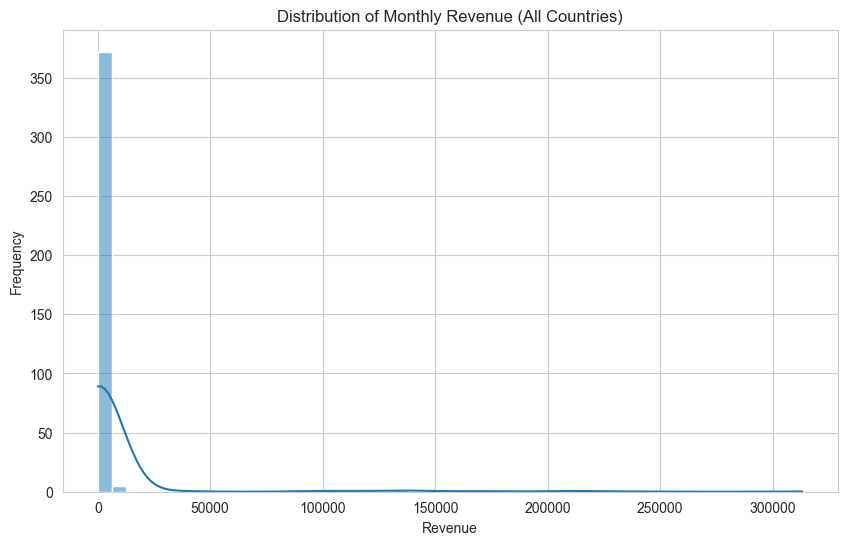

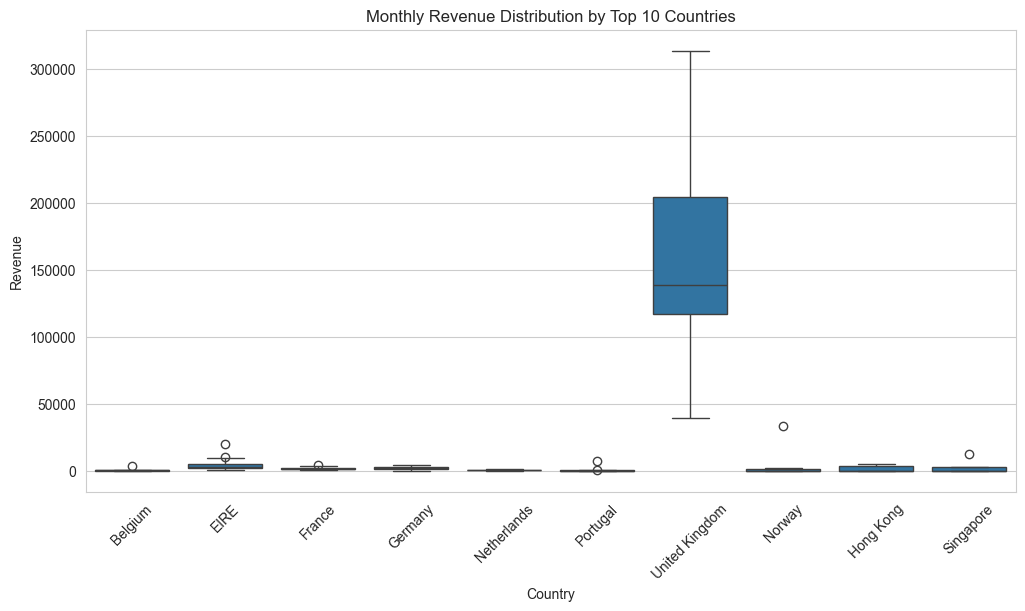

In [21]:
# Revenue histogram
plt.figure(figsize=(10, 6))
sns.histplot(df['revenue'], bins=50, kde=True)
plt.title("Distribution of Monthly Revenue (All Countries)")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()

# Boxplot by country (top 10 only)
plt.figure(figsize=(12, 6))
sns.boxplot(x='country', y='revenue', data=df[df['country'].isin(top_10_countries.index)])
plt.title("Monthly Revenue Distribution by Top 10 Countries")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

## Seasonal Patterns

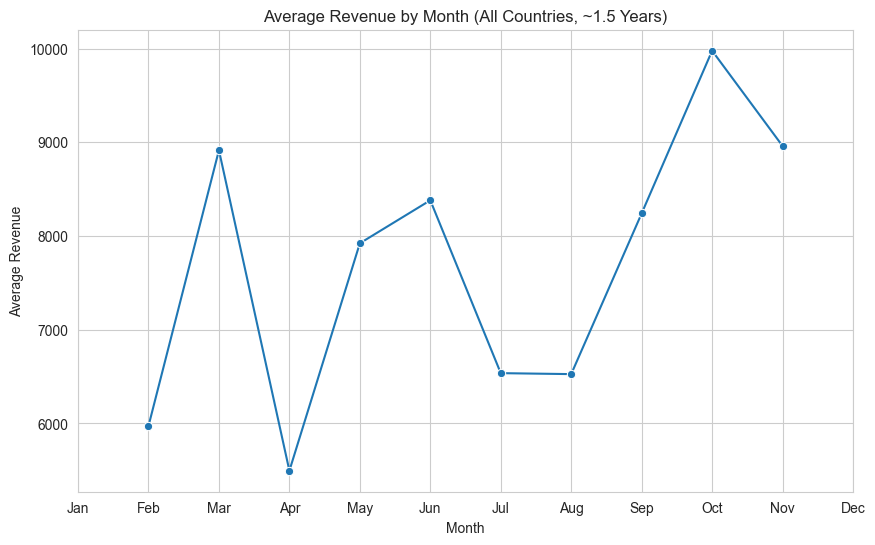

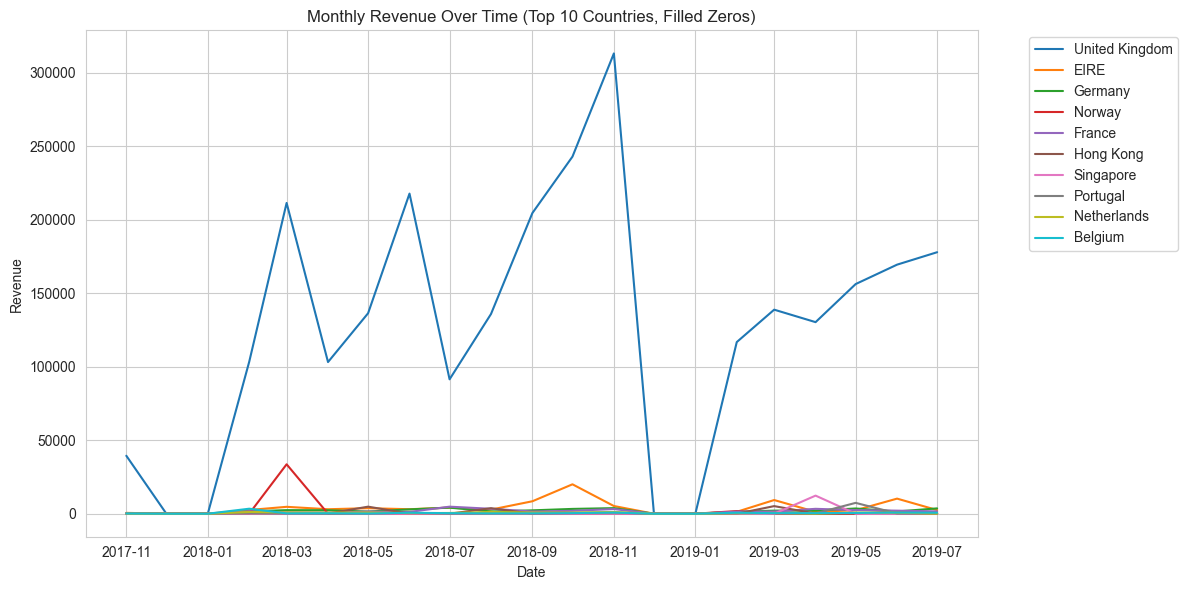

In [22]:
# Average revenue by month
monthly_avg = df.groupby('month')['revenue'].mean()
plt.figure(figsize=(10, 6))
sns.lineplot(x=monthly_avg.index, y=monthly_avg.values, marker='o')
plt.title("Average Revenue by Month (All Countries, ~1.5 Years)")
plt.xlabel("Month")
plt.ylabel("Average Revenue")
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.show()

# Revenue over time (top 10, filled for continuity)
plt.figure(figsize=(12, 6))
date_range = pd.date_range(start=df['date'].min(), end=df['date'].max(), freq='MS')
for country in top_10_countries.index:
    country_data = df[df['country'] == country][['date', 'revenue']].set_index('date')
    country_data = country_data.reindex(date_range, fill_value=0)
    plt.plot(country_data.index, country_data['revenue'], label=country)
plt.title("Monthly Revenue Over Time (Top 10 Countries, Filled Zeros)")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Times Viewed Analysis

Correlation between Revenue and Times Viewed: 0.5081


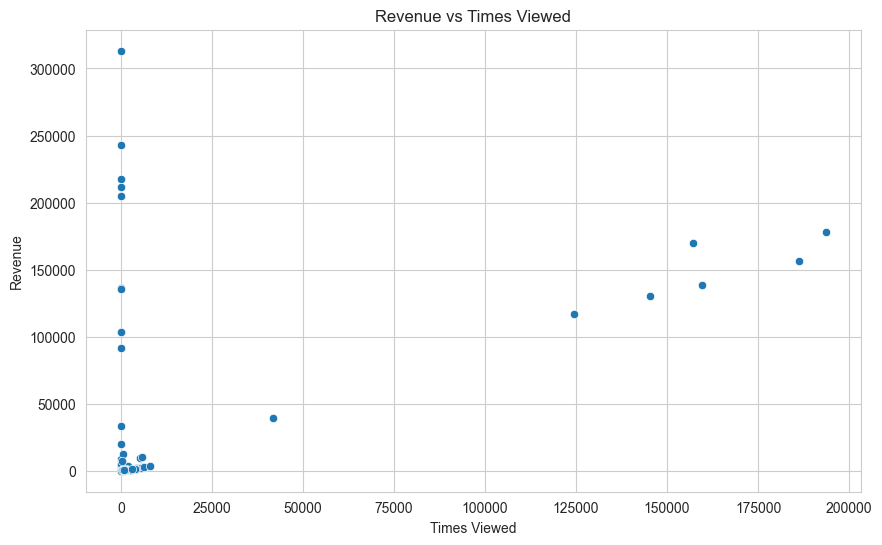

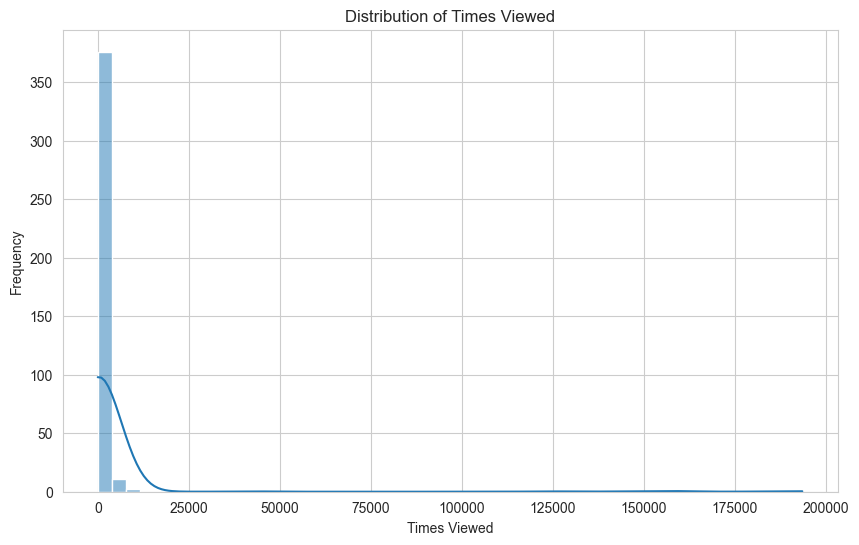

In [23]:
# Correlation between revenue and times_viewed
correlation = df['revenue'].corr(df['times_viewed'])
print(f"Correlation between Revenue and Times Viewed: {correlation:.4f}")

# Scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='times_viewed', y='revenue', data=df)
plt.title("Revenue vs Times Viewed")
plt.xlabel("Times Viewed")
plt.ylabel("Revenue")
plt.show()

# Times viewed distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['times_viewed'], bins=50, kde=True)
plt.title("Distribution of Times Viewed")
plt.xlabel("Times Viewed")
plt.ylabel("Frequency")
plt.show()

## Summary

In [24]:
print(f"- Total countries: {len(df['country'].unique())}")
print(f"- Date range: {df['date'].min()} to {df['date'].max()}")
print(f"- Average months per country: {months_per_country.mean():.1f}")
print(f"- Sparse countries (<12 months): {list(sparse_countries)}")
print(f"- Top 10 countries contribute {top_10_proportion*100:.2f}% of revenue.")
print(f"- Revenue skewness: {df['revenue'].skew():.2f}")
print(f"- Seasonality: Limited data (~1.5 years) suggests possible peaks (e.g., Nov/Dec), but full cycles missing.")
print(f"- Times viewed: Correlation {correlation:.4f} indicates {'' if abs(correlation) > 0.3 else 'weak '}relationship.")
print("- Modeling: Use country flags, lagged revenue. Seasonality uncertain due to short span.")

- Total countries: 43
- Date range: 2017-11-01 00:00:00 to 2019-07-01 00:00:00
- Average months per country: 9.2
- Sparse countries (<12 months): ['Bahrain', 'Bermuda', 'Brazil', 'Canada', 'Czech Republic', 'European Community', 'Greece', 'Hong Kong', 'Iceland', 'Israel', 'Korea', 'Lebanon', 'Lithuania', 'Malta', 'Nigeria', 'Norway', 'RSA', 'Saudi Arabia', 'Singapore', 'Thailand', 'USA', 'United Arab Emirates', 'Unspecified', 'West Indies']
- Top 10 countries contribute 97.58% of revenue.
- Revenue skewness: 5.60
- Seasonality: Limited data (~1.5 years) suggests possible peaks (e.g., Nov/Dec), but full cycles missing.
- Times viewed: Correlation 0.5081 indicates relationship.
- Modeling: Use country flags, lagged revenue. Seasonality uncertain due to short span.


# Analysis of relationship between the relevant data, the target and the business metric

In [25]:
df = ingest.ingest_data(
    input_folders=[TRAIN_DATA_FOLDER_PATH, PRODUCTION_DATA_FOLDER_PATH])

Found 26 JSON files across 2 folders: ['cs-train', 'cs-production']


## Revenue Distribution (target)

Revenue Stats:
count       495.000000
mean       7990.652210
std       36323.241137
min           1.060000
25%          90.075000
50%         248.700000
75%         872.500000
max      313246.222000
Name: revenue, dtype: float64
Skewness: 5.59


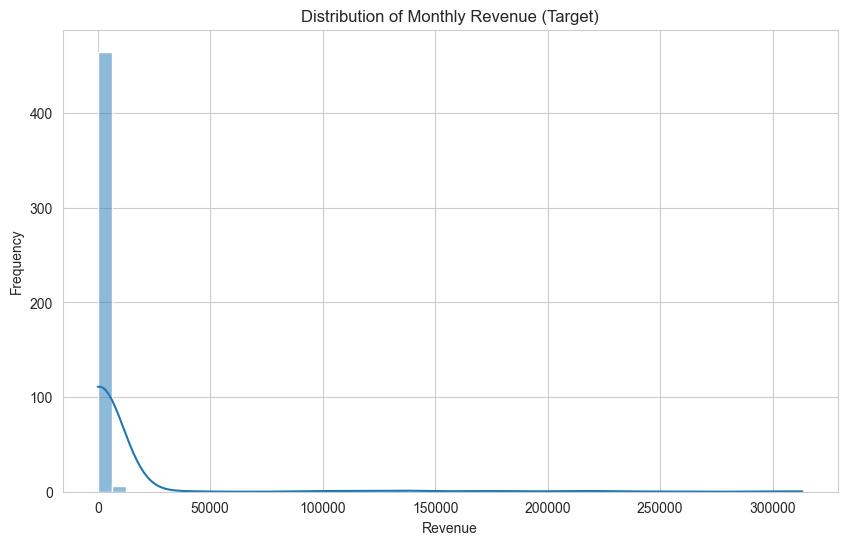

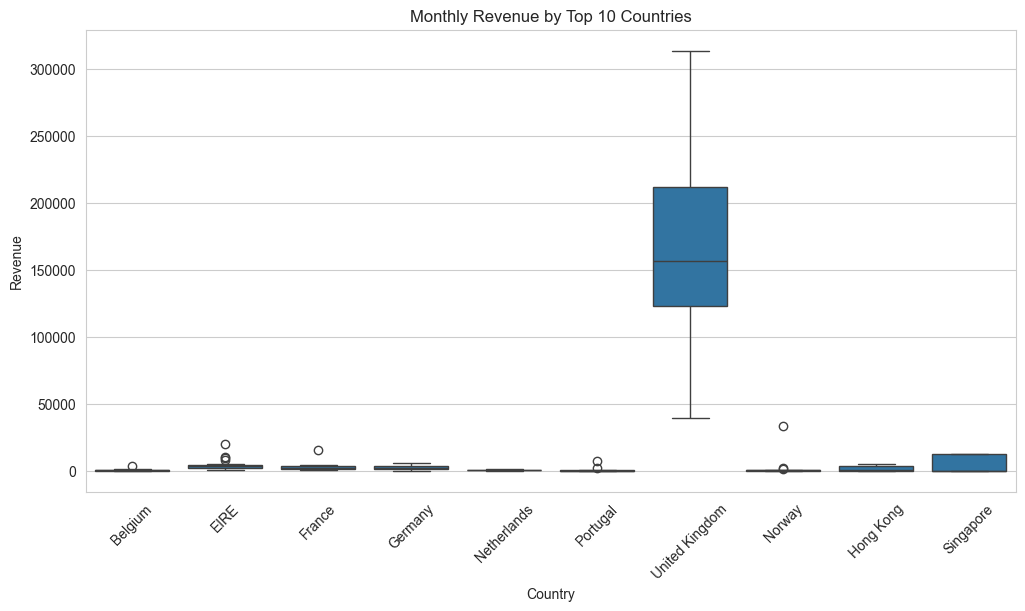

In [26]:
# Summary stats for revenue
print("Revenue Stats:")
print(df['revenue'].describe())
print(f"Skewness: {df['revenue'].skew():.2f}")

# Histogram of revenue
plt.figure(figsize=(10, 6))
sns.histplot(df['revenue'], bins=50, kde=True)
plt.title("Distribution of Monthly Revenue (Target)")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()

# Boxplot by top 10 countries
country_revenue = df.groupby('country')['revenue'].sum().sort_values(ascending=False)
top_10_countries = country_revenue.head(10).index
plt.figure(figsize=(12, 6))
sns.boxplot(x='country', y='revenue', data=df[df['country'].isin(top_10_countries)])
plt.title("Monthly Revenue by Top 10 Countries")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

## Country Impact on Revenue and Business Metric

Total Revenue (Business Metric): 3955372.84
Top 10 Countries Revenue:
country
United Kingdom    3512678.023
EIRE               102602.000
France              59243.080
Germany             57166.681
Norway              40450.580
Singapore           25218.060
Hong Kong           20778.020
Portugal            15399.760
Netherlands         14104.500
Belgium             13566.870
Name: revenue, dtype: float64

Other Countries: 94165.27
Top 10 Proportion: 0.9762 (97.62%)


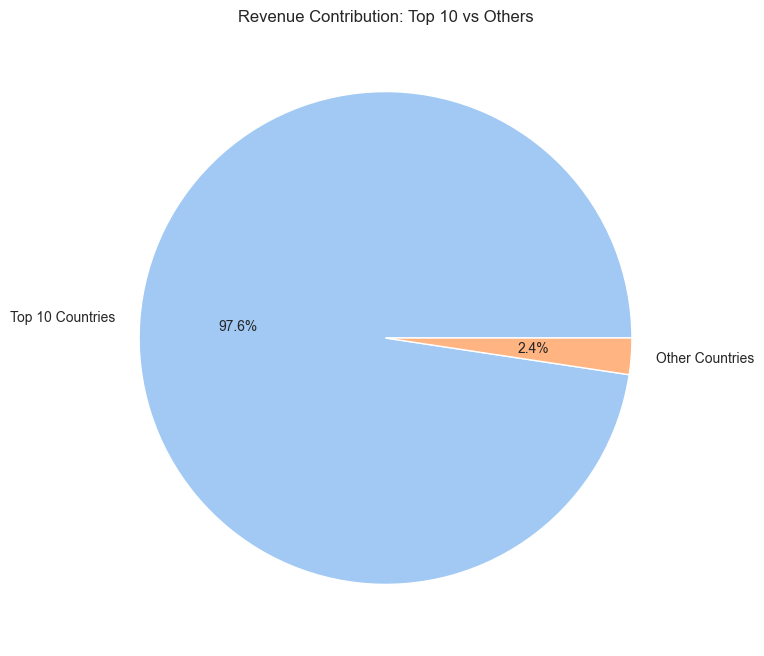

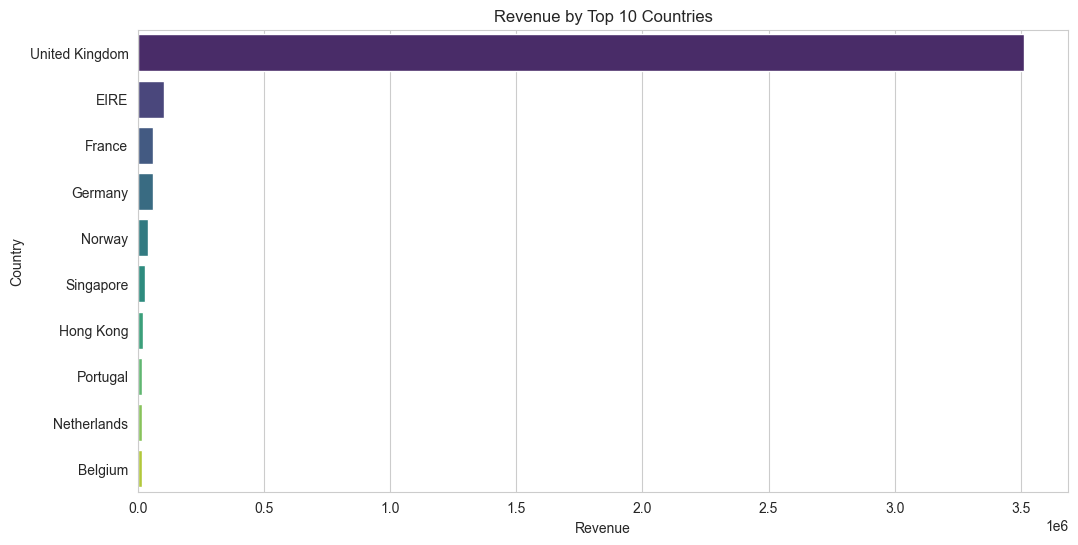

In [27]:
# Total revenue by country
total_revenue = df['revenue'].sum()
top_10_revenue = country_revenue.head(10).sum()
other_revenue = country_revenue[10:].sum()
top_10_proportion = top_10_revenue / total_revenue

# Print stats
print(f"Total Revenue (Business Metric): {total_revenue:.2f}")
print("Top 10 Countries Revenue:")
print(country_revenue.head(10))
print(f"\nOther Countries: {other_revenue:.2f}")
print(f"Top 10 Proportion: {top_10_proportion:.4f} ({top_10_proportion*100:.2f}%)")

# Pie chart
plot_data = pd.Series({
    'Top 10 Countries': top_10_revenue,
    'Other Countries': other_revenue
})
plt.figure(figsize=(8, 8))
plt.pie(plot_data, labels=plot_data.index, autopct='%1.1f%%', colors=sns.color_palette("pastel"))
plt.title("Revenue Contribution: Top 10 vs Others")
plt.show()

# Bar chart
plt.figure(figsize=(12, 6))
sns.barplot(x=country_revenue.head(10).values, y=country_revenue.head(10).index, hue=country_revenue.head(10).index, palette="viridis", legend=False)
plt.title("Revenue by Top 10 Countries")
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.show()

## Seasonality (Month) and Revenue

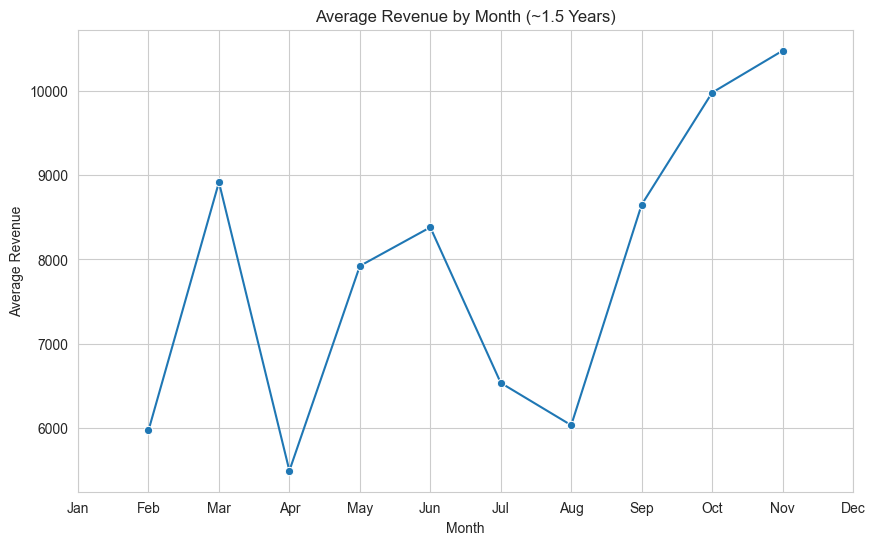

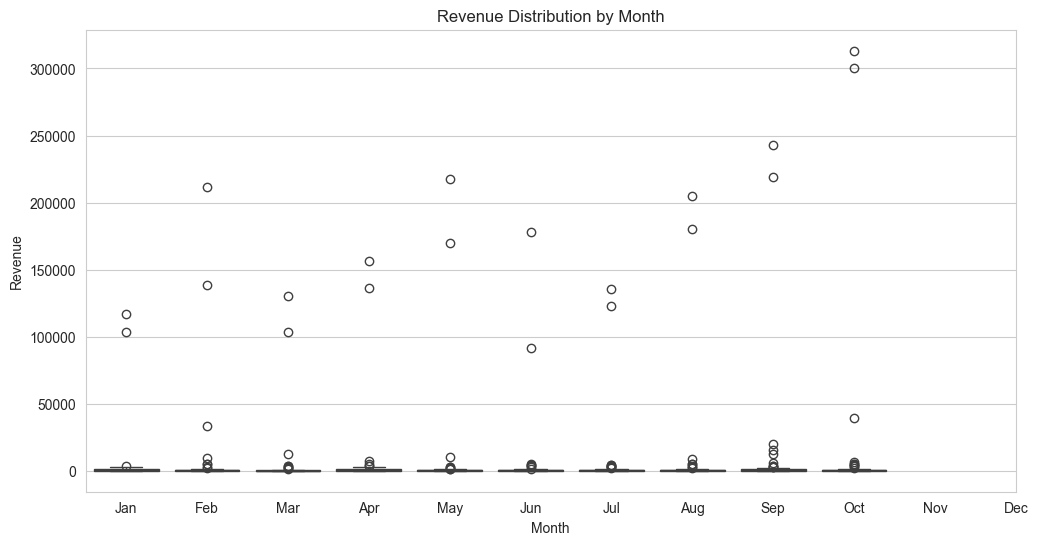

In [28]:
# Average revenue by month
monthly_avg = df.groupby('month')['revenue'].mean()
plt.figure(figsize=(10, 6))
sns.lineplot(x=monthly_avg.index, y=monthly_avg.values, marker='o')
plt.title("Average Revenue by Month (~1.5 Years)")
plt.xlabel("Month")
plt.ylabel("Average Revenue")
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.show()

# Boxplot by month
plt.figure(figsize=(12, 6))
sns.boxplot(x='month', y='revenue', data=df)
plt.title("Revenue Distribution by Month")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(ticks=range(12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.show()

## Times Viewed and Revenue

Correlation between Revenue and Times Viewed: 0.6728


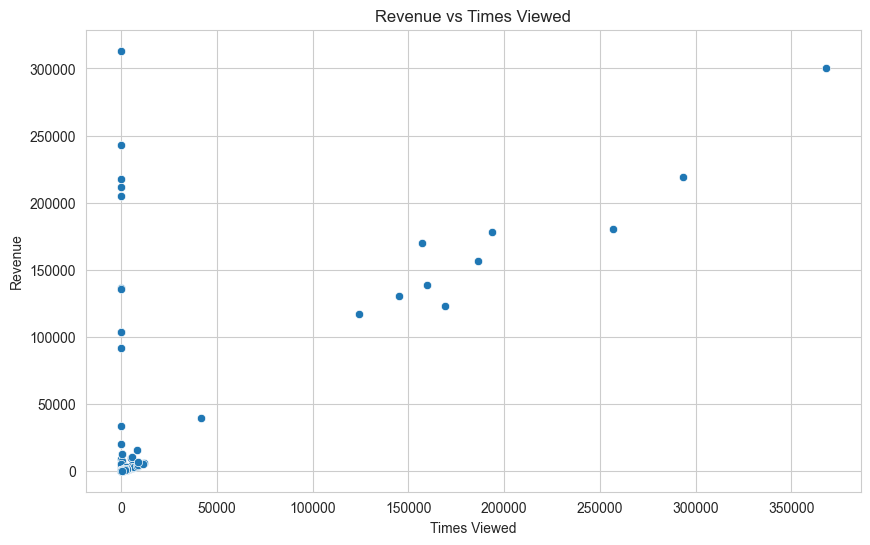

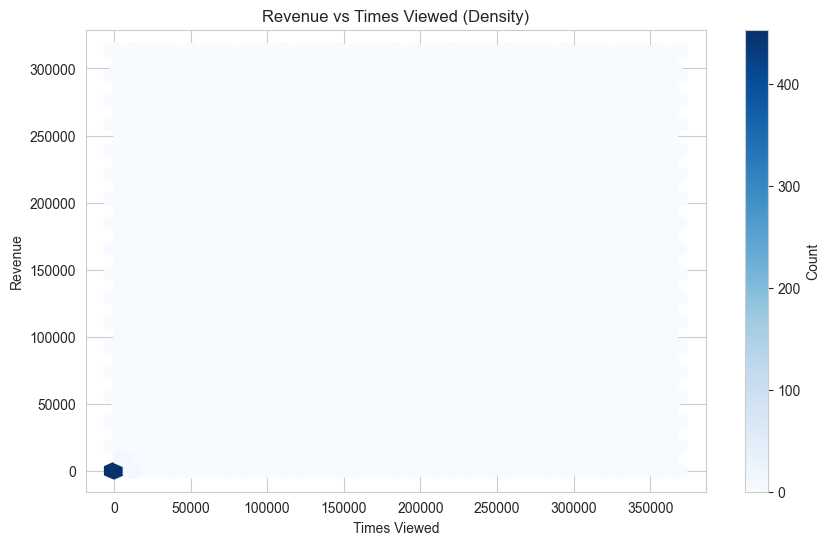

In [29]:
# Correlation
correlation = df['revenue'].corr(df['times_viewed'])
print(f"Correlation between Revenue and Times Viewed: {correlation:.4f}")

# Scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='times_viewed', y='revenue', data=df)
plt.title("Revenue vs Times Viewed")
plt.xlabel("Times Viewed")
plt.ylabel("Revenue")
plt.show()

# Hexbin plot for density
plt.figure(figsize=(10, 6))
plt.hexbin(df['times_viewed'], df['revenue'], gridsize=30, cmap='Blues')
plt.colorbar(label='Count')
plt.title("Revenue vs Times Viewed (Density)")
plt.xlabel("Times Viewed")
plt.ylabel("Revenue")
plt.show()

## Time Trends and Lagged Revenue

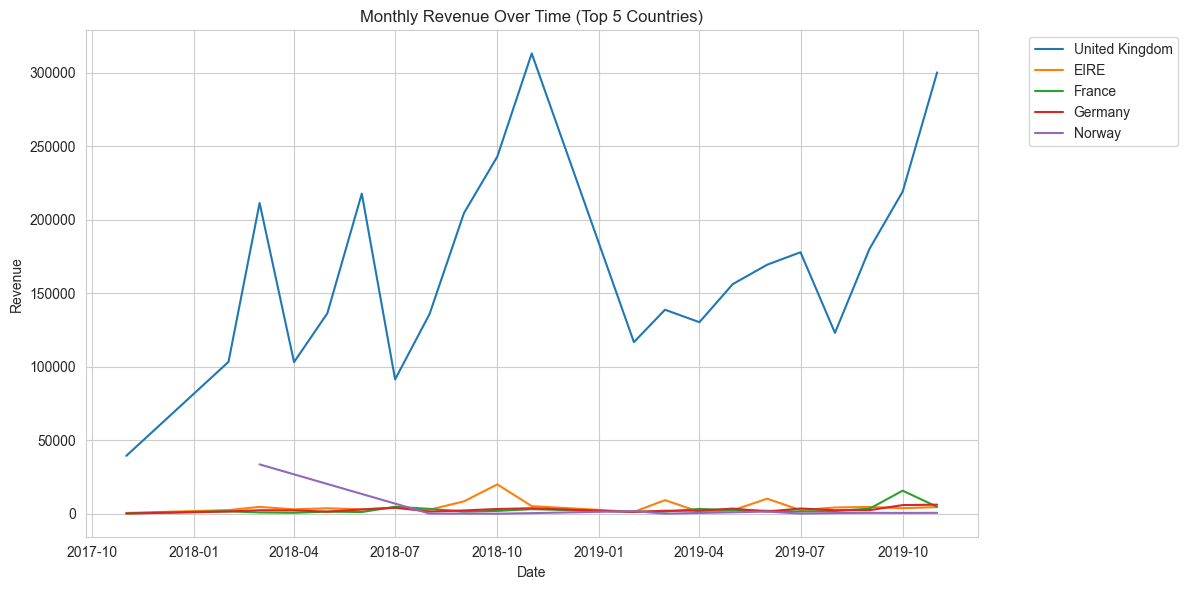

Correlation between Revenue and 1-Month Lagged Revenue: 0.9018


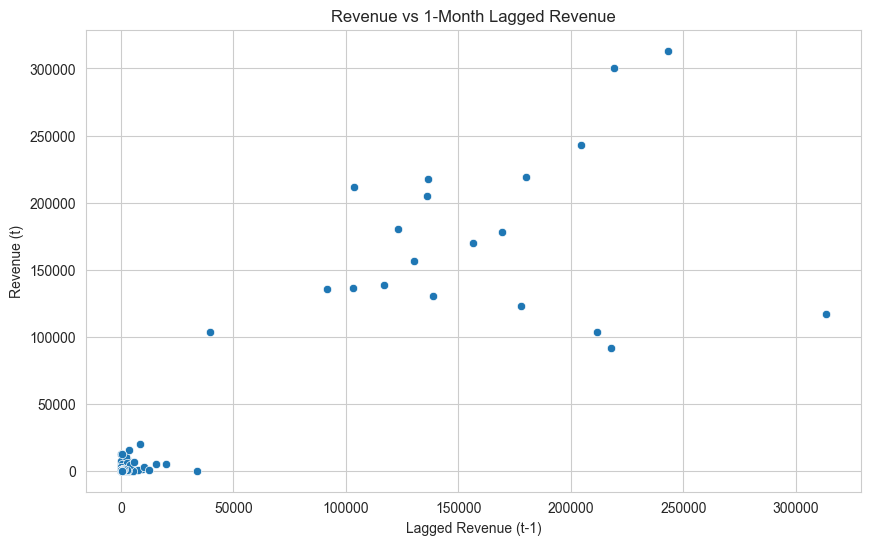

In [30]:
# Revenue over time (top 5 for clarity)
top_5_countries = country_revenue.head(5).index
plt.figure(figsize=(12, 6))
for country in top_5_countries:
    country_data = df[df['country'] == country][['date', 'revenue']].set_index('date')
    plt.plot(country_data.index, country_data['revenue'], label=country)
plt.title("Monthly Revenue Over Time (Top 5 Countries)")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Lagged revenue (1-month lag)
df_lagged = df.copy()
df_lagged['revenue_lag1'] = df_lagged.groupby('country')['revenue'].shift(1)
lag_correlation = df_lagged['revenue'].corr(df_lagged['revenue_lag1'])
print(f"Correlation between Revenue and 1-Month Lagged Revenue: {lag_correlation:.4f}")

# Scatter plot for lag
plt.figure(figsize=(10, 6))
sns.scatterplot(x='revenue_lag1', y='revenue', data=df_lagged)
plt.title("Revenue vs 1-Month Lagged Revenue")
plt.xlabel("Lagged Revenue (t-1)")
plt.ylabel("Revenue (t)")
plt.show()

## Summary

In [31]:
print("Findings for Revenue Prediction:")
print(f"1. Revenue (Target) Distribution:")
print(f"   - Skewness: {df['revenue'].skew():.2f}, right-skewed, suggesting log-transformation for modeling.")
print(f"   - Range: {df['revenue'].min():.2f} to {df['revenue'].max():.2f}, with outliers in top countries.")
print(f"2. Country Impact:")
print(f"   - Top 10 countries contribute {top_10_proportion*100:.2f}% of total revenue ({total_revenue:.2f}).")
print(f"   - Key drivers: {list(top_10_countries[:3])}. Use country flags in model.")
print(f"3. Seasonality (Month):")
print(f"   - Limited data (~1.5 years) shows potential Nov/Dec peaks, but incomplete cycles.")
print(f"   - Include month indicators, but verify with more data.")
print(f"4. Times Viewed:")
print(f"   - Correlation: {correlation:.4f}, weak relationship.")
print(f"   - May add marginal value; consider log-transformation.")
print(f"5. Time Trends and Lags:")
print(f"   - Sparse data limits trends, but top countries show consistency.")
print(f"   - Lagged revenue correlation: {lag_correlation:.4f}, strong for time-series models.")
print(f"6. Business Metric (Total Revenue):")
print(f"   - Dominated by top 10, focus prediction on these for impact.")
print(f"   - Sparse countries (e.g., {list(months_per_country[months_per_country < 12].index)[:3]}) dilute patterns.")


Findings for Revenue Prediction:
1. Revenue (Target) Distribution:
   - Skewness: 5.59, right-skewed, suggesting log-transformation for modeling.
   - Range: 1.06 to 313246.22, with outliers in top countries.
2. Country Impact:
   - Top 10 countries contribute 97.62% of total revenue (3955372.84).
   - Key drivers: ['United Kingdom', 'EIRE', 'France']. Use country flags in model.
3. Seasonality (Month):
   - Limited data (~1.5 years) shows potential Nov/Dec peaks, but incomplete cycles.
   - Include month indicators, but verify with more data.
4. Times Viewed:
   - Correlation: 0.6728, weak relationship.
   - May add marginal value; consider log-transformation.
5. Time Trends and Lags:
   - Sparse data limits trends, but top countries show consistency.
   - Lagged revenue correlation: 0.9018, strong for time-series models.
6. Business Metric (Total Revenue):
   - Dominated by top 10, focus prediction on these for impact.
   - Sparse countries (e.g., ['Bahrain', 'Bermuda', 'Brazil']) di

Recommendations:
- Model Features: Country flags (top 10), month indicators, lagged revenue (1-month).
- Transformations: Log-revenue to handle skewness.
- Business Focus: Prioritize top 10 countries for revenue growth.
- Data Needs: Collect more months to confirm seasonality.